# 30 - Where does the P(k) jitter come from?

Notebook 29 shows ±0.5% jitter in P_on/P_off at m_acc = 10¹¹ GeV for k ≈ 0.05–0.5/Mpc. Leading
hypothesis: the on and off runs sample different k nodes (with C_l output, CLASS sets
k_max_cmb ∝ 1/τ0 and the sink changes τ0), so their spline-interpolation errors do not cancel.

**Null pair:** two sink-off runs that differ only in `k_step_sub` (0.05 vs 0.0505): same physics,
nodes shifted by up to half a step. **Cases:** each is an on/off pair with one precision setting changed.

**Metric:** r(k) = ln(P₁/P₂) minus a smooth degree-6 fit in ln k, on k ∈ [0.02, 2]/Mpc.
Target: max|r| < 10⁻³ (emulator accuracy).

In [1]:
import time
import numpy as np
import matplotlib.pyplot as plt
from classy import Class

BASE = {'omega_b': 0.022383, 'A_s': 2.1005829616811546e-9, 'n_s': 0.96605,
        'tau_reio': 0.0543, 'N_ur': 0.00441, '100*theta_s': 1.041783}
OMEGA_CDM0 = 0.12011
A_REC = 1.0/1091.0
MASS, F_ACC, KAPPA, A_T = 1e11, 0.1, 12.1, 0.133
KM = np.logspace(np.log10(0.02), np.log10(2.0), 400)       # 1/Mpc
# same outputs as nb29: with Cls, k_max_cmb scales as 1/tau0 and shapes the k list
COMMON = {'output': 'tCl,pCl,lCl,mPk', 'lensing': 'yes', 'l_max_scalars': 2500,
          'P_k_max_1/Mpc': 10.0, 'z_max_pk': 0.0,
          'gauge': 'synchronous', 'evolver': 0, 'ncdm_fluid_approximation': 3}


def apply_extra(p, extra):
    """Add precision/output overrides; a value of None removes the key."""
    for key, val in (extra or {}).items():
        if val is None:
            p.pop(key, None)
        else:
            p[key] = val
    return p


def lcdm_params(extra=None):
    p = {**BASE, **COMMON, 'omega_cdm': OMEGA_CDM0,
         'N_ncdm': 1, 'deg_ncdm': '3', 'm_ncdm': '0.02', 'T_ncdm': '0.71611',
         'ncdm_quadrature_strategy': '0', 'ncdm_N_momentum_bins': '15'}
    return apply_extra(p, extra)


def params(sink, extra=None, n_q=51, f_acc=F_ACC):
    ocdm = OMEGA_CDM0/(1 + f_acc*(1 - A_REC**KAPPA)/(1 + (A_REC/A_T)**KAPPA))
    p = {**BASE, **COMMON, 'omega_cdm': ocdm,
         'vary_Gamma_acc': 'yes', 'kappa_acc': KAPPA, 'a_t_acc': A_T,
         'f_acc': f_acc, 'eta_acc': 1e11/MASS,
         'm_acc_in_GeV': MASS, 'm_cdm_in_GeV': MASS,
         'N_ncdm': 2, 'deg_ncdm': '3, 1', 'm_ncdm': '0.02, {:.6e}'.format(MASS*1e9),
         'T_ncdm': '0.71611, 1', 'ncdm_quadrature_strategy': '0, 5',
         'ncdm_N_momentum_bins': '15, {:d}'.format(n_q),
         'acc_de_sink': 'yes' if sink else 'no'}
    return apply_extra(p, extra)


def run(p):
    cosmo = Class()
    cosmo.set(p)
    t0 = time.time()
    try:
        cosmo.compute()
        pk = np.array([cosmo.pk(k, 0.0) for k in KM])
    finally:
        cosmo.struct_cleanup()
        cosmo.empty()
    return pk, time.time() - t0


def noise(p1, p2):
    """Residual of ln(p1/p2) about a smooth degree-6 fit in ln k, with its rms and max."""
    x, y = np.log(KM), np.log(p1/p2)
    r = y - np.polyval(np.polyfit(x, y, 6), x)
    return r, float(np.sqrt(np.mean(r**2))), float(np.max(np.abs(r)))


print('ready: m = {:.0e} GeV, {} k points in [{}, {}] /Mpc'.format(MASS, len(KM), KM[0], KM[-1]))

ready: m = 1e+11 GeV, 400 k points in [0.020000000000000004, 2.0] /Mpc


In [ ]:
CASES = [('default', {}, 51),
         ('k_step_sub 0.02', {'k_step_sub': 0.02}, 51),
         ('k_step_sub 0.01', {'k_step_sub': 0.01}, 51),
         ('k_per_decade_for_bao 200', {'k_per_decade_for_bao': 200}, 51),
         ('tol 1e-6', {'tol_perturbations_integration': 1e-6}, 51),
         ('tol 1e-7', {'tol_perturbations_integration': 1e-7}, 51),
         ('sampling 0.03', {'perturbations_sampling_stepsize': 0.03}, 51),
         ('101 daughter bins', {}, 101),
         ('smooth births', {'accdm_smooth_births': 1}, 51),
         ('mPk only (no Cls)', {'output': 'mPk', 'lensing': None, 'l_max_scalars': None}, 51)]

results = []

# null pair: same physics, k nodes shifted
p_a, t_a = run(params(False))
p_b, t_b = run(params(False, {'k_step_sub': 0.0505}))
r, rms, mx = noise(p_a, p_b)
results.append(dict(case='NULL (off vs off, shifted k nodes)', r=r, rms=rms, max=mx, sec=t_a + t_b))
print('{:<36s} rms {:.1e}  max {:.1e}  ({:.0f} s)'.format(results[-1]['case'], rms, mx, t_a + t_b))

for name, extra, n_q in CASES:
    try:
        p_off, t_off = run(params(False, extra, n_q))
        p_on, t_on = run(params(True, extra, n_q))
    except Exception as err:
        print('{:<36s} FAILED - {}'.format(name, err))
        continue
    r, rms, mx = noise(p_on, p_off)
    results.append(dict(case=name, r=r, rms=rms, max=mx, sec=t_off + t_on))
    print('{:<36s} rms {:.1e}  max {:.1e}  ({:.0f} s)'.format(name, rms, mx, t_off + t_on))

NULL (off vs off, shifted k nodes)   rms 1.6e-03  max 6.8e-03  (30 s)
default                              rms 2.1e-03  max 7.4e-03  (31 s)
k_step_sub 0.02                      rms 1.3e-03  max 9.9e-03  (45 s)
k_step_sub 0.01                      rms 1.2e-03  max 5.6e-03  (61 s)
k_per_decade_for_bao 200             rms 2.2e-03  max 7.1e-03  (33 s)
tol 1e-6                             rms 2.1e-03  max 7.4e-03  (43 s)
tol 1e-7                             FAILED - 

Error in Class: operator()(L:952) :error in perturbations_solve(ppr, pba, pth, ppt, index_md, index_ic, index_k, &pw);
=>perturbations_solve(L:3253) :error in generic_evolver(perturbations_derivs, interval_limit[index_interval], interval_limit[index_interval+1], ppw->pv->y, ppw->pv->used_in_sources, ppw->pv->pt_size, &ppaw, ppr->tol_perturbations_integration, ppr->smallest_allowed_variation, perturbations_timescale, ppr->perturbations_integration_stepsize, ppt->tau_sampling, tau_actual_size, perturbations_sources, perhaps_prin

KeyboardInterrupt: 

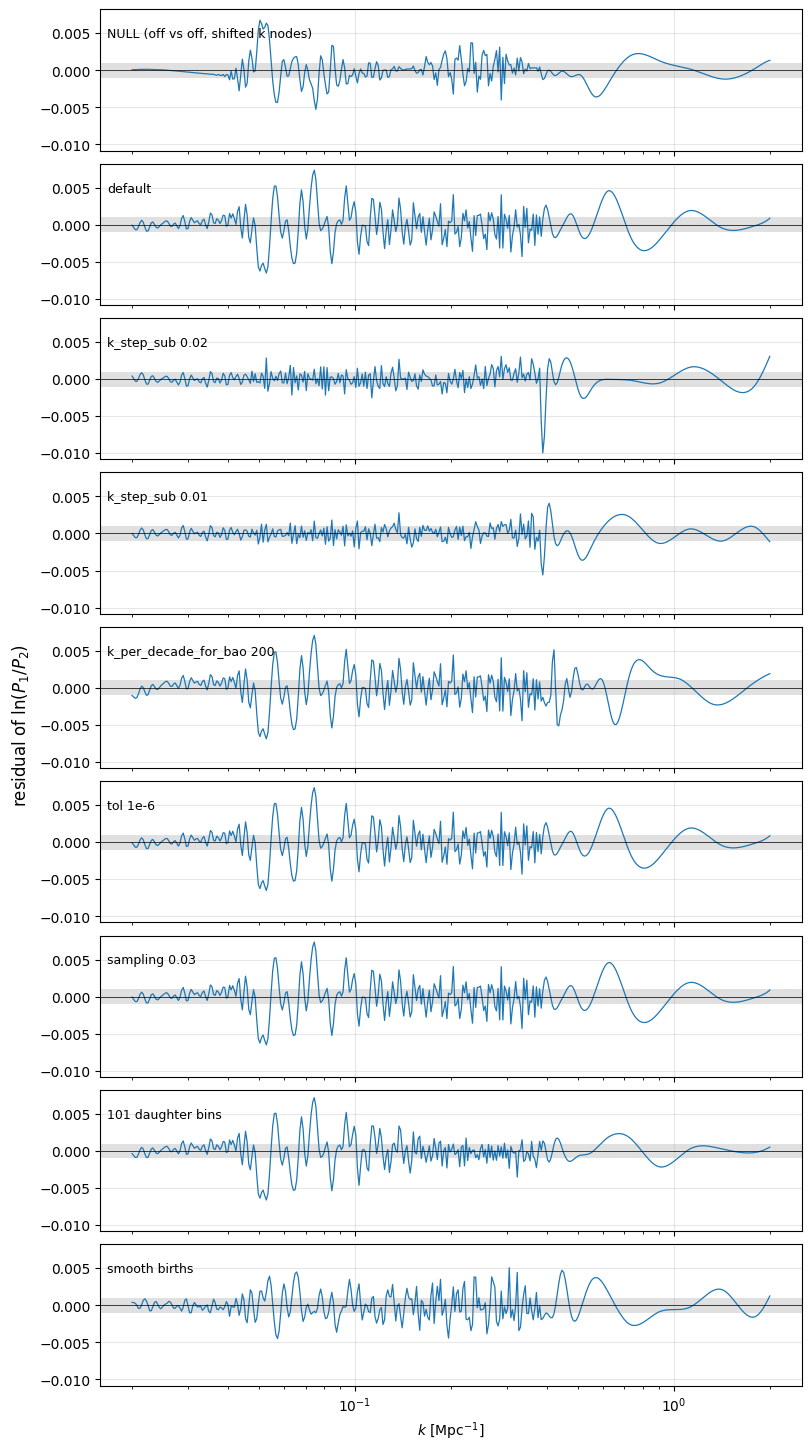

In [ ]:
fig, axes = plt.subplots(len(results), 1, figsize=(8, 1.6*len(results)), sharex=True,
                         sharey=True, constrained_layout=True)
for ax, res in zip(axes, results):
    ax.semilogx(KM, res['r'], lw=0.9)
    ax.axhspan(-1e-3, 1e-3, color='0.88', lw=0)
    ax.axhline(0, color='k', lw=0.5)
    ax.text(0.01, 0.8, res['case'], transform=ax.transAxes, fontsize=9)
    ax.grid(alpha=0.3)
axes[-1].set_xlabel(r'$k\ [\mathrm{Mpc}^{-1}]$')
fig.supylabel(r'residual of $\ln(P_1/P_2)$')
plt.show()

In [ ]:
print('{:<36s} {:>9} {:>9} {:>8}'.format('case', 'rms', 'max', 'seconds'))
for res in results:
    print('{:<36s} {:>9.1e} {:>9.1e} {:>8.0f}'.format(res['case'], res['rms'], res['max'], res['sec']))

passing = [res for res in results[1:] if res['max'] < 1e-3]
null = results[0]
print()
print('null pair max = {:.1e}: grid mismatch alone {} the jitter'.format(
    null['max'], 'reproduces' if null['max'] > 0.3*results[1]['max'] else 'does not reproduce'))
if passing:
    best = min(passing, key=lambda res: res['sec'])
    print('cheapest case below 1e-3: {} ({:.0f} s per pair)'.format(best['case'], best['sec']))
else:
    print('no single setting brings max|r| below 1e-3; combine the two best next')

case                                       rms       max  seconds
NULL (off vs off, shifted k nodes)     1.6e-03   6.8e-03       30
default                                2.1e-03   7.4e-03       31
k_step_sub 0.02                        1.3e-03   9.9e-03       45
k_step_sub 0.01                        1.2e-03   5.6e-03       61
k_per_decade_for_bao 200               2.2e-03   7.1e-03       33
tol 1e-6                               2.1e-03   7.4e-03       43
sampling 0.03                          2.1e-03   7.4e-03       35
101 daughter bins                      1.8e-03   7.2e-03       57
smooth births                          1.8e-03   5.1e-03       36

null pair max = 6.8e-03: grid mismatch alone reproduces the jitter
no single setting brings max|r| below 1e-3; combine the two best next


## Confirming the birth hypothesis

The scan says the error is per k mode, untouched by the integration tolerance, and reduced only by
smoother or finer births. Hypothesis: a daughter bin starts evolving from its pinned state at the last
accepted step before its birth, a lag set by the k-dependent step sequence.

Null pairs (sink off, `k_step_sub` 0.05 vs 0.0505). Predictions: LCDM below 1e-4 (CLASS itself
is clean); f_acc = 0.01 about 10x smaller than f_acc = 0.1 (error scales with the daughter weight).
Also the on/off pair with P(k) output only, which failed above.

In [4]:
SHIFT = {'k_step_sub': 0.0505}
SMOOTH = {'accdm_smooth_births': 1}
MPK_ONLY = {'output': 'mPk', 'lensing': None, 'l_max_scalars': None}
NULLS = [('LCDM', lambda e: lcdm_params(e)),
         ('accDM f_acc = 0.01', lambda e: params(False, e, f_acc=0.01)),
         ('accDM f_acc = 0.1', lambda e: params(False, e)),
         ('accDM f_acc = 0.1, smooth births', lambda e: params(False, {**SMOOTH, **e}))]

null_max = {}
for name, build in NULLS:
    p1, t1 = run(build({}))
    p2, t2 = run(build(SHIFT))
    _, rms, mx = noise(p1, p2)
    null_max[name] = mx
    print('null {:<34s} rms {:.1e}  max {:.1e}  ({:.0f} s)'.format(name, rms, mx, t1 + t2))

p_off, _ = run(params(False, MPK_ONLY))
p_on, _ = run(params(True, MPK_ONLY))
_, rms, mx = noise(p_on, p_off)
print('on/off, mPk only (no Cls)                 rms {:.1e}  max {:.1e}'.format(rms, mx))

print()
print('LCDM null below 1e-4 (CLASS itself is clean): {}'.format(null_max['LCDM'] < 1e-4))
print('f_acc 0.1 / 0.01 null ratio: {:.1f}  (birth hypothesis predicts ~10)'.format(
    null_max['accDM f_acc = 0.1']/null_max['accDM f_acc = 0.01']))

null LCDM                               rms 8.1e-07  max 6.2e-06  (6 s)
null accDM f_acc = 0.01                 rms 1.6e-04  max 7.8e-04  (29 s)
null accDM f_acc = 0.1                  rms 1.6e-03  max 6.8e-03  (31 s)
null accDM f_acc = 0.1, smooth births   rms 1.4e-03  max 4.9e-03  (33 s)
on/off, mPk only (no Cls)                 rms 1.5e-03  max 5.0e-03

LCDM null below 1e-4 (CLASS itself is clean): True
f_acc 0.1 / 0.01 null ratio: 8.7  (birth hypothesis predicts ~10)


## Sampling test: undersampled fine structure?

Hypothesis: the daughter is a sum of discrete momentum bins, so its density contrast carries
undamped oscillations cos(k v_q tau) that re-phase above k ~ 0.01/Mpc (51 bins), with a period of
roughly 5e-4/Mpc in k. CLASS samples P(k) with spacing ~k_step_sub * 2pi/r_s, so at the default step
the oscillations are aliased into apparent per-mode noise.

Null pairs (sink off, k_step_sub vs 1.01 k_step_sub). Prediction if the hypothesis holds: the residual
collapses once the step resolves the oscillations (around 0.005), and 201 bins is lower at every step.

n_q =  51  k_step_sub = 0.05   rms 1.6e-03  max 6.8e-03  (13 s per run)
n_q =  51  k_step_sub = 0.02   rms 9.7e-04  max 7.6e-03  (17 s per run)
n_q =  51  k_step_sub = 0.01   rms 6.4e-04  max 3.1e-03  (25 s per run)
n_q =  51  k_step_sub = 0.005  rms 1.2e-03  max 5.2e-03  (43 s per run)
n_q = 201  k_step_sub = 0.05   rms 1.4e-03  max 6.8e-03  (52 s per run)
n_q = 201  k_step_sub = 0.02   rms 9.2e-04  max 9.8e-03  (63 s per run)
n_q = 201  k_step_sub = 0.01   rms 5.4e-04  max 3.2e-03  (100 s per run)
n_q = 201  k_step_sub = 0.005  rms 5.9e-04  max 4.8e-03  (162 s per run)

k_step_sub     max, 51 bins    max, 201 bins
      0.05          6.8e-03          6.8e-03
      0.02          7.6e-03          9.8e-03
      0.01          3.1e-03          3.2e-03
     0.005          5.2e-03          4.8e-03


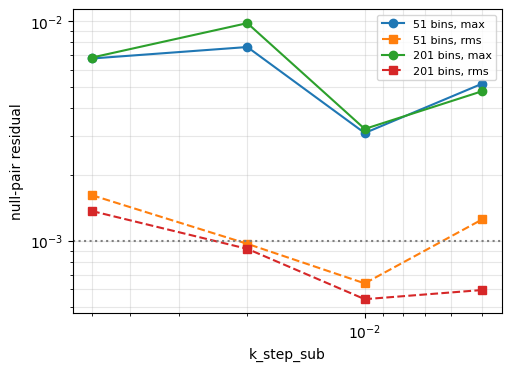

In [2]:
STEPS = [0.05, 0.02, 0.01, 0.005]
BINS = [51, 201]
sampling = {}
for n_q in BINS:
    for step in STEPS:
        try:
            p1, t1 = run(params(False, {'k_step_sub': step}, n_q))
            p2, t2 = run(params(False, {'k_step_sub': 1.01*step}, n_q))
        except Exception as err:
            print('n_q = {}, k_step_sub = {}: FAILED - {}'.format(n_q, step, err))
            continue
        _, rms, mx = noise(p1, p2)
        sampling[(n_q, step)] = (rms, mx)
        print('n_q = {:>3d}  k_step_sub = {:<6g} rms {:.1e}  max {:.1e}  ({:.0f} s per run)'.format(
            n_q, step, rms, mx, 0.5*(t1 + t2)))

print()
print('{:>10} '.format('k_step_sub') + ' '.join('{:>16}'.format('max, {} bins'.format(n)) for n in BINS))
for step in STEPS:
    print('{:>10g} '.format(step) + ' '.join(
        '{:>16}'.format('{:.1e}'.format(sampling[(n, step)][1]) if (n, step) in sampling else 'failed')
        for n in BINS))

fig, ax = plt.subplots(figsize=(5, 3.6), constrained_layout=True)
for n in BINS:
    steps = [s for s in STEPS if (n, s) in sampling]
    ax.loglog(steps, [sampling[(n, s)][1] for s in steps], 'o-', label='{} bins, max'.format(n))
    ax.loglog(steps, [sampling[(n, s)][0] for s in steps], 's--', label='{} bins, rms'.format(n))
ax.axhline(1e-3, color='grey', ls=':')
ax.invert_xaxis()
ax.set_xlabel('k_step_sub')
ax.set_ylabel('null-pair residual')
ax.legend(fontsize=8)
ax.grid(alpha=0.3, which='both')
plt.show()